# Day 7: Session 7B - Name the Columns, Not the Colours

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7b_seaborn.html)

Date: 09/09/2026

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://eds-217-essential-python.github.io/data/messy_field_survey.csv'
survey = pd.read_csv(url)

survey = survey.drop_duplicates()

survey['site'] = survey['site'].str.strip()
survey['site'] = survey['site'].str.lower()
survey['site'] = survey['site'].str.replace('-', '_')

survey['pH'] = survey['pH'].str.replace(',', '.')
survey['pH'] = survey['pH'].astype(float)

survey = survey.dropna(subset=['temperature_c', 'dissolved_oxygen_mg_L', 'conductivity_uS_cm'])
survey['n_replicates'] = survey['n_replicates'].fillna(1)
survey['n_replicates'] = survey['n_replicates'].astype(int)

survey = survey[survey['temperature_c'] > -100].copy()
survey = survey.rename(columns={'collection date': 'collection_date'})

survey.shape

(255, 7)

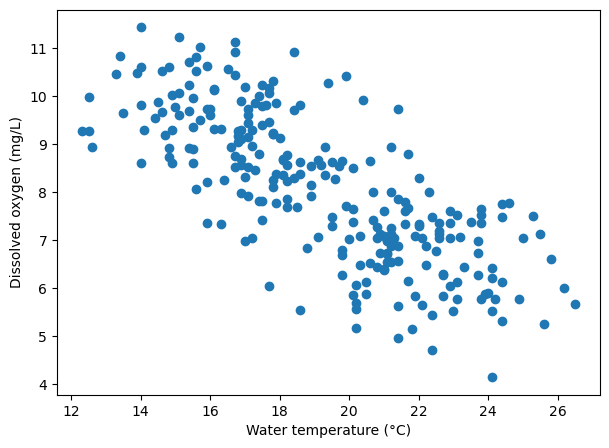

In [3]:
# the above cleaned up all the data so that we could work with it easier

# now lets create a scatter plot of it all

plt.figure(figsize=(7, 5))

plt.scatter(survey['temperature_c'], survey['dissolved_oxygen_mg_L'])

plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')
plt.show()

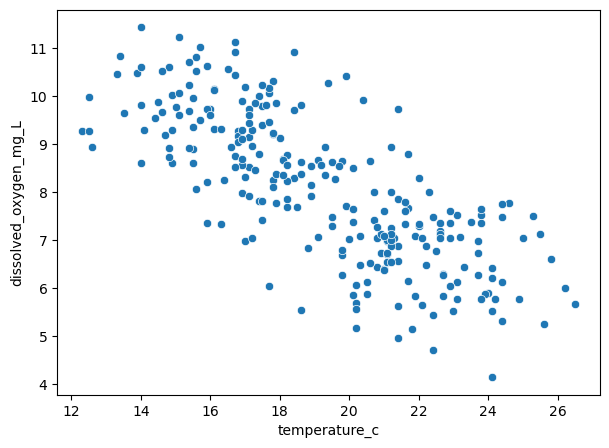

In [ ]:
# now lets do the above in seaborn

plt.figure(figsize=(7, 5))

sns.scatterplot(data=survey, x='temperature_c', y='dissolved_oxygen_mg_L')

plt.show()

#sns uses different syntax, using a data frame and two columns from that data

Text(0, 0.5, 'Dissolved oxygen (mg/L)')

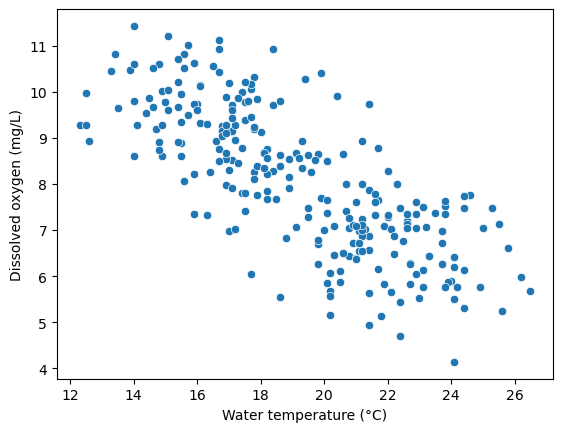

In [5]:
# sns uses the column names as axis names, which isnt always great
# you can override this by specifying the axis names

sns.scatterplot(data=survey, x='temperature_c', y='dissolved_oxygen_mg_L')
plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')

In [6]:
# these are some data that we would love to plot

print(survey.groupby('site')['dissolved_oxygen_mg_L'].mean().sort_values())
print(survey.groupby('site')['temperature_c'].mean().sort_values())

site
site_f     6.180233
site_c     6.873111
site_e     7.410930
site_b     8.601220
site_a     9.485909
site_d    10.053333
Name: dissolved_oxygen_mg_L, dtype: float64
site
site_d    15.179487
site_a    16.600000
site_b    18.102439
site_e    19.730233
site_c    21.911111
site_f    23.297674
Name: temperature_c, dtype: float64


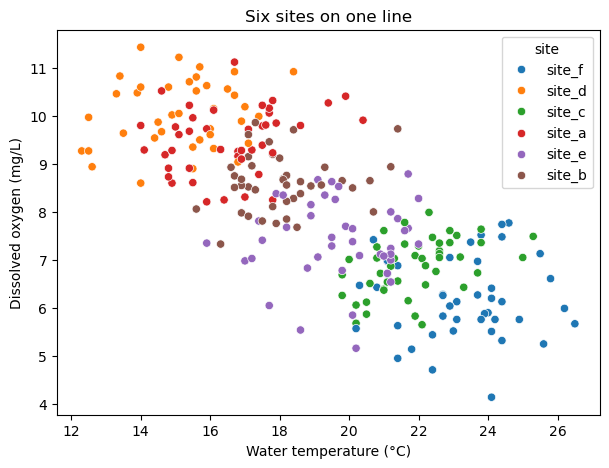

In [7]:
# now lets plot those two sets of data

plt.figure(figsize=(7, 5))

sns.scatterplot(data=survey, x='temperature_c', y='dissolved_oxygen_mg_L', hue='site')

plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')
plt.title('Six sites on one line')
plt.show()

In [ ]:
# hue= breaks things up by whatever you choose, this time 'site'
# use hue= to break things up into groups, like sites, species, etc

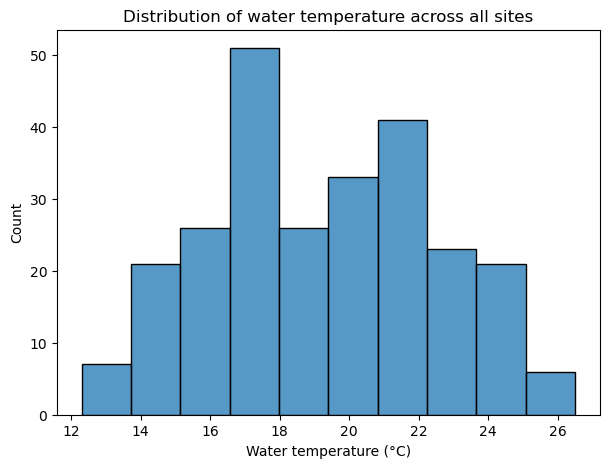

In [8]:
# and here is a histogram in sns
plt.figure(figsize=(7, 5))

sns.histplot(data=survey, x='temperature_c')

plt.xlabel('Water temperature (°C)')
plt.title('Distribution of water temperature across all sites')
plt.show()

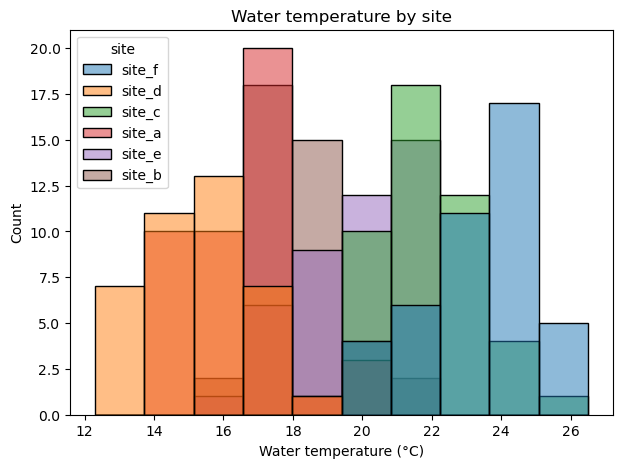

In [9]:
# now lets use hue= on it
plt.figure(figsize=(7, 5))

sns.histplot(data=survey, x='temperature_c', hue='site')

plt.xlabel('Water temperature (°C)')
plt.title('Water temperature by site')
plt.show()

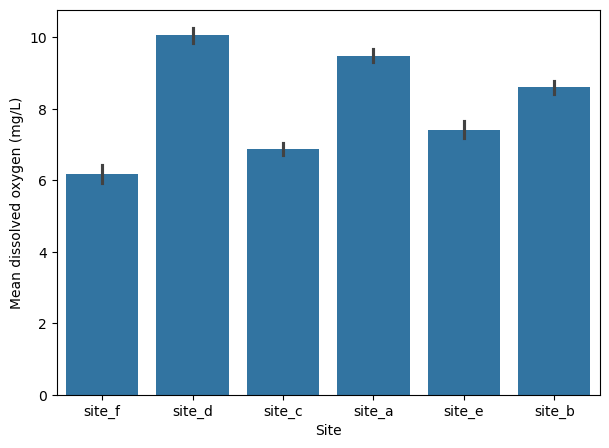

In [10]:
# okay now what about a barplot
plt.figure(figsize=(7, 5))

sns.barplot(data=survey, x='site', y='dissolved_oxygen_mg_L')

plt.xlabel('Site')
plt.ylabel('Mean dissolved oxygen (mg/L)')
plt.show()

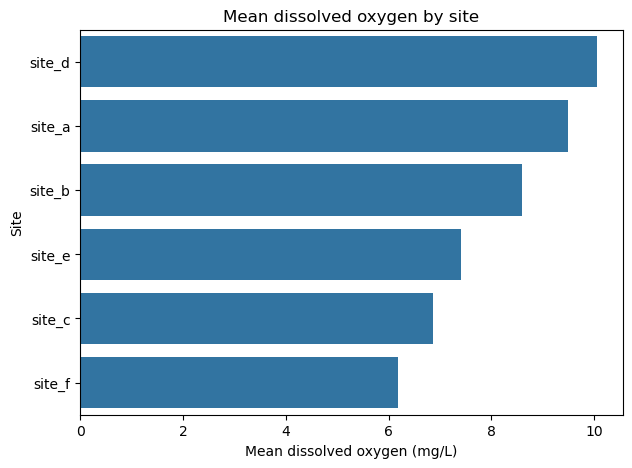

In [13]:
# the above chart is unorganized, and has uncertainty ticks that don't make sense
# lets make another one that is much more pretty, but we will have to 
# hand compute values first and hand them to sns

# first compute the values desired
mean_do = survey.groupby('site')['dissolved_oxygen_mg_L'].mean().sort_values(ascending=False)

mean_do.round(2)

# now plug this into sns bar chart

plt.figure(figsize=(7, 5))

sns.barplot(x=mean_do.values, y=mean_do.index)

plt.xlabel('Mean dissolved oxygen (mg/L)')
plt.ylabel('Site')
plt.title('Mean dissolved oxygen by site')
plt.show()

In [14]:
# we can make the above graph with vertical bars or horizontal bars, depending on the how you write the call
sns.barplot(x=series.values, y=series.index)   # horizontal bars, sorted as you sorted them
sns.barplot(y=series.values, x=series.index)   # vertical bars, same data

NameError: name 'series' is not defined

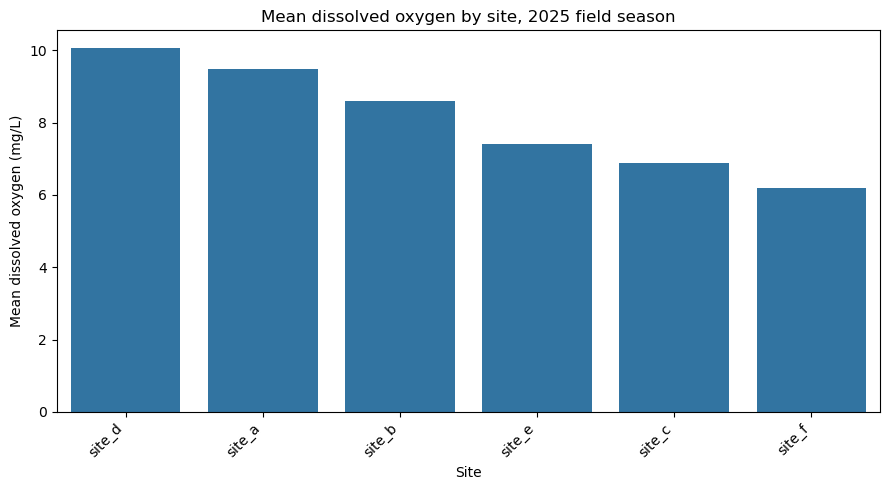

In [15]:
# seaborn uses matplotlib arguements and defaults, so you can
# combine the same calls and arguments (?) to it

plt.figure(figsize=(9, 5))

sns.barplot(x=mean_do.index, y=mean_do.values)

plt.xlabel('Site')
plt.ylabel('Mean dissolved oxygen (mg/L)')
plt.title('Mean dissolved oxygen by site, 2025 field season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()